# Dense MNIST with Keras 3 — PyTorch Backend

This complete workflow implements the dense MNIST experiment from the
[Neural Networks](../index.md) chapter in **Keras 3 — PyTorch backend**.

The official 60,000-example training collection is divided with a seeded,
stratified split into 50,000 training and 10,000 validation samples. The
official 10,000-example test set remains untouched until final evaluation.

The example uses five epochs. To run it more quickly, set `EPOCHS` to 1 or 2
in the data-loading cell.

The notebook is self-contained in Google Colab. Select **Runtime → Run all**;
the runtime will use its installed PyTorch stack. The Keras alternative uses
that same runtime through the Keras 3 high-level API.

## Runtime dependency check

In [1]:
import importlib.util

required = {'keras': 'keras', 'torch': 'torch'}
missing = [
    package for module, package in required.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    raise RuntimeError(
        "Missing notebook dependencies: "
        + ", ".join(missing)
        + ". Locally run `uv sync --group notebooks`; Colab normally "
        "provides these frameworks, so restart the runtime and try again."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional notebook uses the same Torch runtime as the canonical PyTorch
path. `compile()` selects the loss and optimizer, `fit()` owns the explicit
epoch/batch loop shown in the canonical PyTorch workflow, and callbacks provide the
high-level hook for training control.

## Imports and reproducibility

In [3]:
import hashlib
import os

os.environ["KERAS_BACKEND"] = "torch"

import matplotlib.pyplot as plt
import numpy as np
import torch
import keras
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

Keras 3.15.1; backend=torch; PyTorch 2.13.0


## Load data and create the shared split

In [4]:
SEED = 42
EPOCHS = 5  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128  # Number of images used for each parameter update.

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)  # Prefer repeatable operations when available.

(x_development, y_development), (x_test, y_test) = keras.datasets.mnist.load_data()
all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=10_000,
    random_state=SEED,
    stratify=y_development,
)

split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices]
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices]
x_test = x_test.astype("float32") / 255.0

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: 829d1431018b38bc
train=50,000, validation=10,000, test=10,000, epochs=5


## Inspect class coverage

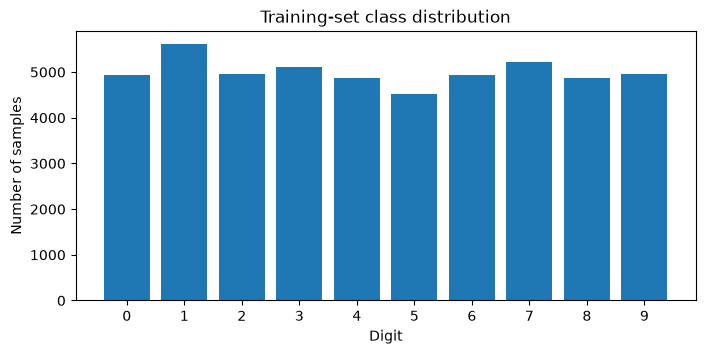

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Digit",
    ylabel="Number of samples",
    xticks=np.arange(10),
)
plt.show()

## Model configuration

This complete workflow preserves the source architecture and dropout rate.

In [6]:
DROPOUT_RATE = 0.5
print(f"dropout rate: {DROPOUT_RATE}")

dropout rate: 0.5


## Build the dense classifier

In [7]:
model = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(200, activation="relu"),
        layers.Dense(150, activation="relu"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(10),
    ],
    name="dense_mnist",
)
model.compile(
    optimizer=keras.optimizers.Adam(),  # Adam updates the model weights.
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # Classification error.
    metrics=["accuracy"],
)
model.summary()

Model: "dense_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,660 (736.95 KB)

 Trainable params: 188,660 (736.95 KB)

 Non-trainable params: 0 (0.00 B)

## Train with validation evidence

In [8]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

Epoch 1/5


391/391 - 3s - 7ms/step - accuracy: 0.8777 - loss: 0.4109 - val_accuracy: 0.9532 - val_loss: 0.1618


Epoch 2/5


391/391 - 2s - 6ms/step - accuracy: 0.9519 - loss: 0.1623 - val_accuracy: 0.9637 - val_loss: 0.1194


Epoch 3/5


391/391 - 2s - 6ms/step - accuracy: 0.9662 - loss: 0.1139 - val_accuracy: 0.9696 - val_loss: 0.1050


Epoch 4/5


391/391 - 2s - 6ms/step - accuracy: 0.9743 - loss: 0.0865 - val_accuracy: 0.9722 - val_loss: 0.0935


Epoch 5/5


391/391 - 2s - 6ms/step - accuracy: 0.9785 - loss: 0.0711 - val_accuracy: 0.9750 - val_loss: 0.0861


## Inspect learning curves

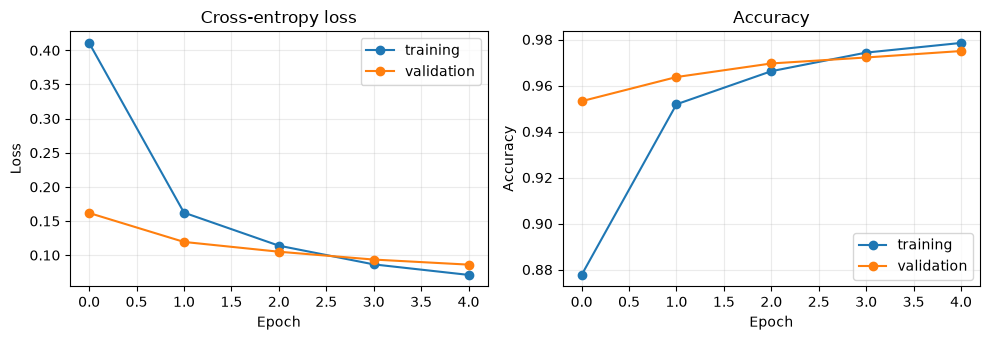

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history["loss"], marker="o", label="training")
axes[0].plot(history.history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
axes[1].plot(history.history["accuracy"], marker="o", label="training")
axes[1].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluate once on the held-out test set

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
test_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predictions = test_logits.argmax(axis=1)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))

print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
assert cm.shape == (10, 10)

test loss: 0.0822
test accuracy: 0.9755
              precision    recall  f1-score   support

           0      0.984     0.989     0.986       980
           1      0.990     0.992     0.991      1135
           2      0.980     0.972     0.976      1032
           3      0.941     0.981     0.961      1010
           4      0.974     0.977     0.975       982
           5      0.975     0.979     0.977       892
           6      0.981     0.977     0.979       958
           7      0.973     0.973     0.973      1028
           8      0.986     0.950     0.968       974
           9      0.971     0.964     0.968      1009

    accuracy                          0.976     10000
   macro avg      0.976     0.975     0.975     10000
weighted avg      0.976     0.976     0.976     10000



## Inspect class-level errors

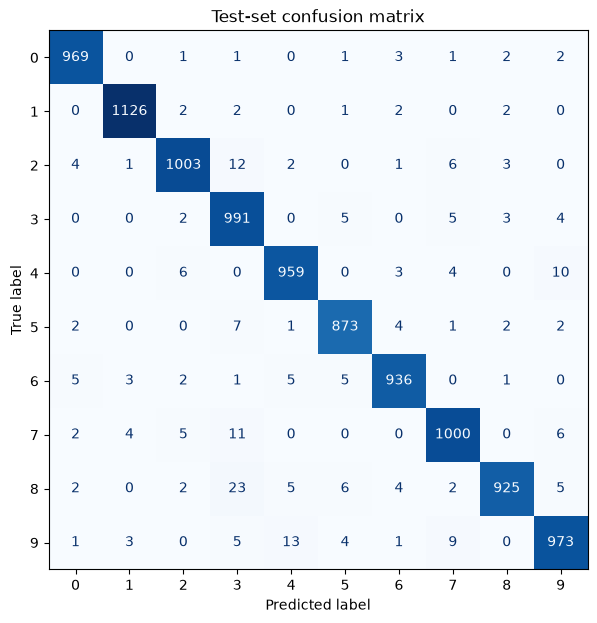

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Test-set confusion matrix")
plt.show()

## Inspect representative mistakes

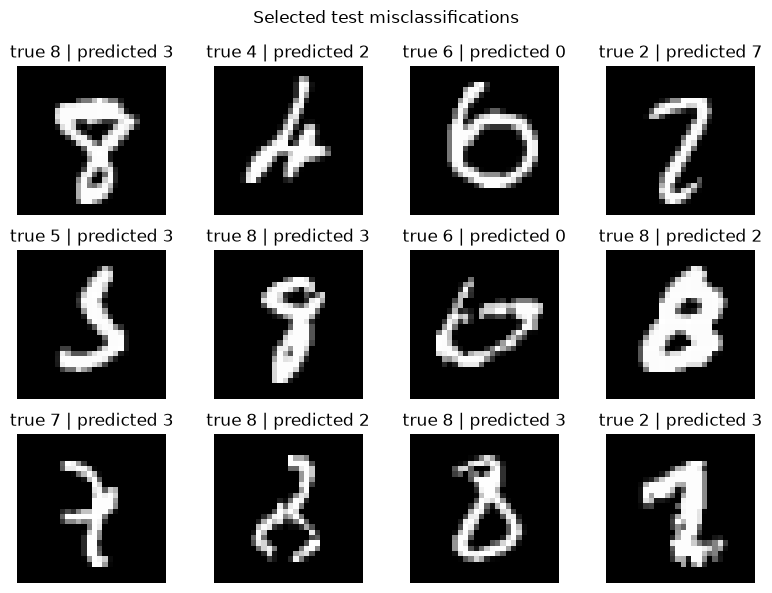

In [12]:
wrong = np.flatnonzero(test_predictions != y_test)
chosen = wrong[:12]
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for axis, sample_index in zip(axes.flat, chosen):
    axis.imshow(x_test[sample_index], cmap="gray")
    axis.set_title(
        f"true {y_test[sample_index]} | predicted {test_predictions[sample_index]}"
    )
    axis.axis("off")
for axis in axes.flat[len(chosen):]:
    axis.axis("off")
fig.suptitle("Selected test misclassifications")
plt.tight_layout()
plt.show()

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- change dropout from `0.5` to `0.25` and compare the validation curves.
- change one dense-layer width and inspect the parameter count.
- try a smaller Adam learning rate while keeping the split fixed.